In [26]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sns.set_theme()

pd.set_option('display.max_columns', None)
# 1. Load your financial data
# Replace 'financial_returns.csv' with your actual file path (CSV, Excel, etc.)
# We assume dates are in the first column and set them as the index

df = pd.read_csv('./data/concat_hf_data.csv', parse_dates=True).set_index('date')
df.index = pd.to_datetime(df.index)

# df = df.drop(columns=['arr', 'm1', 'tidan', 'bam'], axis=1)
# df = df[['bam', 'four_world', 'quanstream', 'm1', 'vadantia', 'sp500', 'arr']]
# 2. Compute the correlation matrix
# 'min_periods' ensures we have at least N overlapping data points 
# to trust the correlation score. Adjust this based on your dataset size.
# corr_matrix = df.corr(method='pearson', min_periods=3)
df = df[
        [   
        'quanstream', 
        'm1', 
        'vadantia', 
        'enko', 
        # 'brummer', 
        'wizard_quant', 
        'arr', 
        'r_squared', 
        # 'boothbay', 
        'shiprock', 
        # 'singularity_mf', 
        'grasshoper',
        'edge_capital'
        ]
    ]
df.head()

,quanstream,m1,vadantia,enko,wizard_quant,arr,r_squared,shiprock,grasshoper,edge_capital
date,,,,,,,,,,
2000-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df = df[df.index >= pd.to_datetime('2023-01-01')]

WIZARD_QUANT_LEVERAGE = True

if WIZARD_QUANT_LEVERAGE:
    df['wizard_quant'] *= 2 - 0.04 / 12

df.head()

,quanstream,m1,vadantia,enko,wizard_quant,arr,r_squared,shiprock,grasshoper,edge_capital
date,,,,,,,,,,
2023-01-01,0.049672,0.0183,-0.0558,0.0026,-0.018769,0.0495,0.0281,0.0552,NaN,0.0430
2023-02-01,0.060202,0.0449,-0.0315,-0.0056,0.022363,-0.0420,-0.0414,0.0004,NaN,0.0677
2023-03-01,0.000532,0.0507,-0.0656,-0.0338,0.068486,0.0603,-0.0067,-0.0455,NaN,0.0651
2023-04-01,0.013402,0.0189,-0.0788,-0.0656,0.092845,-0.0105,0.0254,0.0173,NaN,0.0727
2023-05-01,0.048232,-0.0039,0.2106,0.1033,0.032146,0.0222,0.0133,0.0703,NaN,0.0095


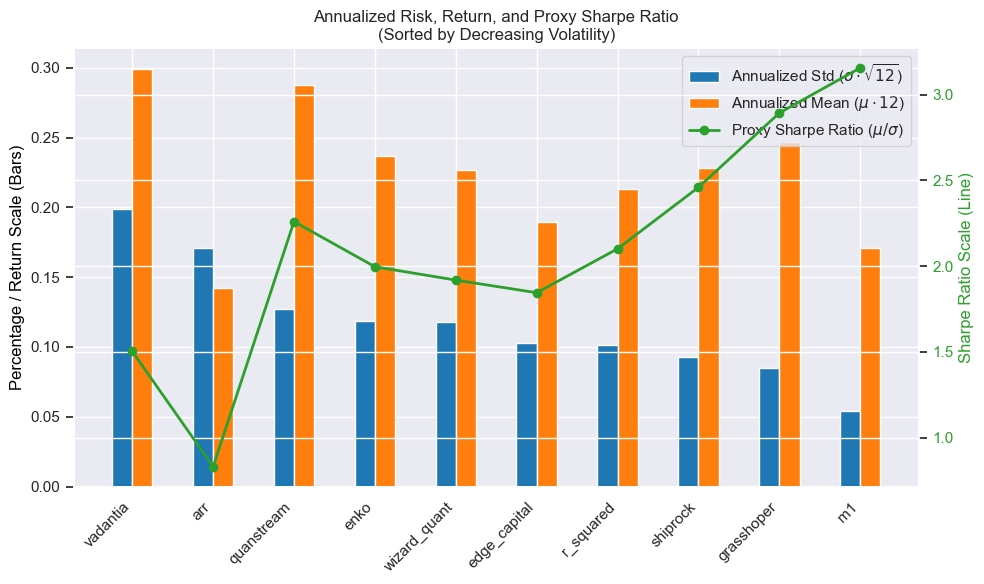

In [28]:
# 2. Compute annualized metrics
stats_df = pd.DataFrame(
    {
        "Annualized Mean": df.mean() * 12,
        "Annualized Std": df.std() * np.sqrt(12),
    }
)

# Calculate the Proxy Sharpe Ratio
stats_df["Proxy Sharpe"] = stats_df["Annualized Mean"] / stats_df["Annualized Std"]

# 3. Sort by decreasing standard deviation
stats_df = stats_df.sort_values(by="Annualized Std", ascending=False)

# 4. Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(stats_df.index))  # Label locations
width = 0.25  # Slightly narrower bars to accommodate the layout cleanly

# Plot the Mean and Std bars on the primary left y-axis (ax1)
rects1 = ax1.bar(
    x - width / 2,
    stats_df["Annualized Std"],
    width,
    label="Annualized Std ($\sigma \cdot \sqrt{12}$)",
    color="#1f77b4",
)
rects2 = ax1.bar(
    x + width / 2,
    stats_df["Annualized Mean"],
    width,
    label="Annualized Mean ($\mu \cdot 12$)",
    color="#ff7f0e",
)

# Labeling the primary axis
ax1.set_ylabel("Percentage / Return Scale (Bars)", color="black")
ax1.set_xticks(x)
ax1.set_xticklabels(stats_df.index, rotation=45, ha="right")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Create the secondary y-axis on the right (ax2) for the ratio
ax2 = ax1.twinx()
(line,) = ax2.plot(
    x,
    stats_df["Proxy Sharpe"],
    color="#2ca02c",
    marker="o",
    linewidth=2,
    markersize=6,
    label="Proxy Sharpe Ratio ($\mu / \sigma$)",
)

# Labeling the secondary axis
ax2.set_ylabel("Sharpe Ratio Scale (Line)", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

# Combine legends from both axes into a single legend box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title(
    "Annualized Risk, Return, and Proxy Sharpe Ratio\n(Sorted by Decreasing Volatility)"
)
plt.tight_layout()
plt.show()

In [29]:
# 1. Compute the equal-weight portfolio returns
# df.mean(axis=1) automatically assigns equal weight across the 10 funds for each month.
eq_portfolio_return = df.mean(axis=1)

# 2. Compute relevant statistics
ann_mean_eq = eq_portfolio_return.mean() * 12
ann_std_eq = eq_portfolio_return.std() * np.sqrt(12)
sharpe_eq = ann_mean_eq / ann_std_eq
skew_eq = eq_portfolio_return.skew()
kurt_eq = eq_portfolio_return.kurtosis()

# Maximum Drawdown calculation
cumulative_returns_eq = (1 + eq_portfolio_return).cumprod()
peak_eq = cumulative_returns_eq.cummax()
drawdown_eq = (cumulative_returns_eq - peak_eq) / peak_eq
max_dd_eq = drawdown_eq.min()

print("Equal Weight Portfolio Statistics:")
print("-" * 30)
print(f"Annualized Mean:       {ann_mean_eq*100:.2f}%")
print(f"Annualized Volatility: {ann_std_eq*100:.2f}%")
print(f"Proxy Sharpe Ratio:    {sharpe_eq:.4f}")
print(f"Skewness:              {skew_eq:.4f}")
print(f"Kurtosis:              {kurt_eq:.4f}")
print(f"Maximum Drawdown:      {max_dd_eq*100:.2f}%")


Equal Weight Portfolio Statistics:
------------------------------
Annualized Mean:       22.08%
Annualized Volatility: 3.97%
Proxy Sharpe Ratio:    5.5609
Skewness:              1.0268
Kurtosis:              1.7719
Maximum Drawdown:      -0.08%


In [ ]:
# 1. Define the leverage multipliers for each fund
multipliers = {
    'quanstream': 1.0,
    # 'four_world': 2.0,
    'm1': 2,
    'vadantia': 1,
    'enko': 1.0,
    'brummer': 1.0*1.5,
    'wizard_quant': 1.0,
    # 'global_sigma': 2.0,
    'arr': 1.0,
    # 'cambrian': 1.0,
    'grasshoper':2,
    'r_squared':1
}

net_returns = []

# 2. Process the dataframe row by row
for index, row in df.iterrows():
    # Identify which funds have data for this month
    active_mask = row.notna()
    num_active = active_mask.sum()
    
    if num_active == 0:
        net_returns.append(np.nan)
        continue
        
    # Base equal weight is distributed only among the active funds
    base_weight = 1.0 / num_active
    
    # Calculate individual weights by applying the multipliers
    row_weights = pd.Series(0.0, index=df.columns)
    for fund in df.columns:
        if active_mask[fund]:
            row_weights[fund] = base_weight * multipliers[fund]
            
    # Calculate extra exposure and financing cost for this specific month
    total_exposure = row_weights.sum()
    extra_exposure = max(0, total_exposure - 1.0)
    monthly_financing_cost = (extra_exposure * 0.04) / 12.0
    
    # Gross return (NaNs are ignored by filling with 0 since their weight is also 0)
    gross_return = (row.fillna(0) * row_weights).sum()
    
    # Net return
    net_return = gross_return - monthly_financing_cost
    net_returns.append(net_return)

# Create the final time series and drop any fully empty months
net_portfolio_return = pd.Series(net_returns, index=df.index).dropna()

# 3. Compute relevant statistics
ann_mean = net_portfolio_return.mean() * 12
ann_std = net_portfolio_return.std() * np.sqrt(12)
sharpe = ann_mean / ann_std
skew = net_portfolio_return.skew()
kurt = net_portfolio_return.kurtosis()

# Maximum Drawdown calculation
cumulative_returns = (1 + net_portfolio_return).cumprod()
peak = cumulative_returns.cummax()
drawdown = (cumulative_returns - peak) / peak
max_dd = drawdown.min()

print("Dynamic Leveraged Portfolio Statistics:")
print("-" * 30)
print(f"Annualized Mean:       {ann_mean*100:.2f}%")
print(f"Annualized Volatility: {ann_std*100:.2f}%")
print(f"Proxy Sharpe Ratio:    {sharpe:.4f}")
print(f"Skewness:              {skew:.4f}")
print(f"Kurtosis:              {kurt:.4f}")
print(f"Maximum Drawdown:      {max_dd*100:.2f}%")


In [31]:
cumulative_returns.plot()

NameError: name 'cumulative_returns' is not defined

In [ ]:
net_portfolio_return

date
2023-01-01    0.009250
2023-02-01   -0.002536
2023-03-01    0.001993
2023-04-01   -0.002864
2023-05-01    0.054393
2023-06-01    0.037700
2023-07-01    0.016593
2023-08-01   -0.009236
2023-09-01    0.015993
2023-10-01    0.009136
2023-11-01    0.023186
2023-12-01    0.015307
2024-01-01    0.009429
2024-02-01    0.022102
2024-03-01    0.047483
2024-04-01    0.011677
2024-05-01    0.016190
2024-06-01    0.028365
2024-07-01    0.024058
2024-08-01    0.015577
2024-09-01    0.028952
2024-10-01    0.004333
2024-11-01    0.031146
2024-12-01    0.021952
2025-01-01    0.027615
2025-02-01    0.026190
2025-03-01    0.030433
2025-04-01    0.006433
2025-05-01    0.010765
2025-06-01    0.009840
2025-07-01    0.013433
2025-08-01    0.016440
2025-09-01    0.063574
2025-10-01    0.029638
2025-11-01    0.025710
2025-12-01    0.002131
2026-01-01    0.039781
2026-02-01    0.015752
2026-03-01    0.004295
2026-04-01    0.014274
2026-05-01    0.031667
dtype: float64

In [ ]:
import pandas as pd

# 1. Combine both time series into a single DataFrame
results_df = pd.DataFrame({
    'Baseline (Equal Weight)': eq_portfolio_return,
    'Leveraged (Dynamic)': net_portfolio_return
}).dropna()

# 2. Compute the cumulative product for each calendar year
# We group by the index's year, compute the cumulative product, and subtract 1
yearly_returns = (1 + results_df).groupby(results_df.index.year).prod() - 1

# 3. Convert to percentages and round for clean formatting
yearly_returns_pct = (yearly_returns * 100).round(2)

# 4. Display the output
print("Yearly Cumulative Returns (%)")
print("-" * 40)
print(yearly_returns_pct)


Yearly Cumulative Returns (%)
----------------------------------------
      Baseline (Equal Weight)  Leveraged (Dynamic)
date                                              
2023                    16.55                18.06
2024                    23.29                29.40
2025                    22.64                29.43
2026                     7.83                10.99
